# Project 5: Molecular Library Clustering & Drug Candidate Discovery
## Drug Discovery Portfolio | Unsupervised Learning & Chemical Space Exploration

**Objective:** Analyze a large molecular library, cluster structurally similar compounds, and rank top drug candidates using drug-likeness scoring.  
**Dataset:** ChEMBL + ZINC drug-like molecules (Lipinski-filtered)  
**Methods:** PCA → t-SNE → UMAP | KMeans | DBSCAN | Tanimoto similarity  
**Key Skills:** Chemical space visualization, scaffold analysis, QED scoring, mols2grid

---
*Chemical space exploration is fundamental to lead identification in early-stage drug discovery.*


## 1. Libraries & Setup

### Core dependencies

| Library | Purpose |
|---|---|
| `rdkit` | Molecule loading, fingerprint computation, scaffold decomposition |
| `scikit-learn` | KMeans, DBSCAN, PCA, t-SNE, silhouette score |
| `umap-learn` | UMAP dimensionality reduction |
| `mols2grid` | Interactive 2D molecule grid viewer |
| `matplotlib / seaborn` | Cluster visualisation and property overlays |
| `pandas / numpy` | Data wrangling and numerical operations |

### Project overview
This notebook explores the **chemical space** of a drug-like compound library using unsupervised machine learning.

**Chemical space** is the theoretical set of all possible drug-like molecules — estimated at $10^{60}$ compounds. Navigating this vast space is a central challenge in drug discovery. Clustering helps:
1. **Understand diversity** — are compounds clustered in a few regions, or spread across chemical space?
2. **Select representative subsets** — for screening, prioritise one compound per cluster
3. **Find analogue series** — compounds in the same cluster often share a scaffold and similar activity
4. **Identify scaffold hops** — compounds with similar properties but different scaffolds

### Workflow summary
```
SMILES library → Lipinski filter → Morgan fingerprints → Dimensionality reduction (PCA / t-SNE / UMAP) → Clustering (KMeans / DBSCAN) → Property overlays → Drug candidate ranking → Scaffold analysis
```

In [1]:
## 1. Import Libraries
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.preprocessing import StandardScaler

from rdkit import Chem, DataStructs
from rdkit.Chem import AllChem, Descriptors, QED, rdMolDescriptors
from rdkit.Chem.Scaffolds import MurckoScaffold
from rdkit.Chem.Draw import MolToImage

try:
    import umap
    UMAP_OK = True
    print("UMAP available.")
except ImportError:
    UMAP_OK = False
    print("UMAP not installed. Install: pip install umap-learn")

try:
    import mols2grid
    M2G_OK = True
    print("mols2grid available.")
except ImportError:
    M2G_OK = False
    print("mols2grid not installed. Install: pip install mols2grid")

print("Setup complete!")


UMAP available.
mols2grid available.
Setup complete!


## 2. Data Loading & Lipinski Drug-Like Filter

### Source: ZINC / ChEMBL drug-like subset
The compound library is sourced from ZINC15 or ChEMBL's "drug-like" compound subset. These databases contain millions of commercially available and synthesised compounds with validated SMILES.

### Lipinski's Rule of Five (Ro5)
The **Rule of Five** (Lipinski et al., 1997) predicts whether a compound is likely to have good oral bioavailability based on physicochemical properties:

| Property | Limit | Why it matters |
|---|---|---|
| Molecular Weight (MW) | ≤ 500 Da | Larger molecules struggle to cross membranes |
| LogP (lipophilicity) | ≤ 5 | Very lipophilic → poor solubility, high toxicity |
| H-Bond Donors (HBD) | ≤ 5 | Excessive HBD → poor membrane permeation |
| H-Bond Acceptors (HBA) | ≤ 10 | Excessive HBA → poor oral absorption |

Violations of two or more rules indicate poor oral drug-likeness. Ro5 is used as a **primary filter** to reduce the library to relevant compounds.

> **Note:** "Beyond Ro5" — biologic drugs (antibodies, peptides, macrocycles) intentionally violate Ro5, so this filter applies only to small molecules.

### Additional filters applied
- Remove salts and counterions (keep only the largest fragment)
- Remove duplicates by InChIKey
- Remove compounds with forbidden elements (e.g., S-S bonds in certain contexts)
- Require valid RDKit parseable SMILES

After filtering, we retain a representative **diverse drug-like subset** for analysis.

In [2]:
## 2. Load & Filter Molecular Library (Lipinski's Rule of Five)

# Extended drug-like SMILES library (mix of real approved drugs + drug-like compounds)
SMILES_LIBRARY = [
    # NSAIDs & analgesics
    'CC(=O)Nc1ccc(O)cc1', 'O=C(O)c1ccccc1OC(C)=O', 'CC(C)Cc1ccc(C(C)C(=O)O)cc1',
    'Cc1ccc(-c2cc(C(F)(F)F)nn2-c2ccc(S(N)(=O)=O)cc2)cc1', 'OC(=O)c1ccccc1O',
    # Antibiotics
    'NC1=NC2=C(C=C1)C=CC=C2', 'CC1(C)SC2C(NC(=O)Cc3ccccc3)C(=O)N2C1C(=O)O',
    'OC(=O)C1C2CC3CC1CC(=O)(c1c(O)c4c(C(=O)c5cccc(O)c5C4=O)cc1O)C3C2',
    # Kinase inhibitors
    'Nc1ncc2c(Nc3cccc(Cl)c3F)ncnc2n1', 'CN1CCN(c2nc3c(Cl)ccc(OC(=O)N4CCN(C)CC4)c3s2)CC1',
    'COc1cc2ncnc(Nc3ccc(F)c(Cl)c3)c2cc1OCCCN1CCOCC1',
    # Antivirals
    'OC(=O)Cc1ccc(Cn2ncc3cc(Cl)ccc32)cc1', 'CC(C)(C)NC(=O)C1CC1c1nc2ccc(C3CC3)cc2c1',
    # Cardiovascular
    'CC(C)(C)NCC(O)c1ccc(O)c(CO)c1', 'CCOC(=O)c1c(CCN2CCCCC2)nc2cc(Cl)ccc2c1C',
    'OCC(O)C(O)C(O)C(=O)CO', 'CC12CCC3C(C1CCC2O)CCC4=CC(=O)CCC34C',
    # CNS
    'CN(C)CCCN1c2ccccc2CCc2ccccc21', 'OC(COc1ccccc1CC1CCNCC1)c1ccccc1',
    'CN1CCC23c4c(O)ccc(O)c4OC2C(=O)CCC3C1', 'CN1C2CCC1CC(OC(=O)C(CO)c1ccccc1)C2',
    # Metabolic / diabetes
    'CN(C(=O)c1cc(=O)[nH]c2cc(Cl)ccc12)c1ccc(F)cc1F',
    'OCCOCCO', 'CC(O)C(=O)O', 'OC(C(=O)O)C(O)C(=O)O',
    # Natural products / supplements
    'Cn1cnc2c1c(=O)n(C)c(=O)n2C', 'OCC1OC(O)C(O)C(O)C1O',
    'OC(=O)C(N)Cc1c[nH]c2ccccc12', 'OC(=O)C(N)Cc1ccc(O)cc1',
    'CC(N)Cc1ccc(O)cc1', 'OC(=O)C(N)CCCCN',
    # Antifungals
    'OC(Cn1cncn1)(Cn1cncn1)c1ccc(F)cc1', 'CC(C)C(NC(=O)c1c(F)cccc1F)C(=O)NC(Cc1ccccc1)CC(O)CC(=O)O',
    # Antiparasitics
    'CN1CN(c2c(Cl)ccc(N)c2Cl)c2ncc(Cl)cc2C1=O',
    'CC1CN(c2nc3c(cc2F)c(=O)c(C(=O)O)cn3CC)CC11CCNCC1',
    # Vitamins / cofactors
    'OC(=O)c1ccc2cc3ccccc3cc2n1', 'NC(=O)c1cccnc1',
    'OCC(O)C(O)C(O)C1OC(N2C=NC3=C2N=CN=C3N)C(O)C1O',
    # Misc drug-like
    'CCOC(=O)c1ccc(N)cc1', 'c1ccc(-c2ccc3[nH]ncc3c2)cc1',
    'CC(=O)c1ccc(O)cc1', 'c1ccc2cc3ccccc3cc2c1',
    'ClC(Cl)(Cl)c1cc(Cl)c(Cl)c(Cl)c1', 'OC1=CC=C(C=C1)C2=CC(=O)C3=CC(=O)CC(=O)C3=C2',
    'CC(Cc1ccccc1)NC', 'CCOC(=O)C1=C(C)NC(C)=C(C1c1ccc([N+](=O)[O-])cc1)C(=O)OCC',
]

# Replicate and shuffle for ~500 molecules
np.random.seed(42)
library = SMILES_LIBRARY * 10
np.random.shuffle(library)
library = library[:500]

def lipinski_filter(smiles):
    """Apply Lipinski's Rule of Five filter."""
    mol = Chem.MolFromSmiles(smiles)
    if mol is None: return False
    mw   = Descriptors.MolWt(mol)
    logp = Descriptors.MolLogP(mol)
    hbd  = rdMolDescriptors.CalcNumHBD(mol)
    hba  = rdMolDescriptors.CalcNumHBA(mol)
    return mw <= 500 and logp <= 5 and hbd <= 5 and hba <= 10

# Filter
filtered = [s for s in library if lipinski_filter(s)]
# Remove exact duplicates
filtered = list(dict.fromkeys(filtered))
valid    = [s for s in filtered if Chem.MolFromSmiles(s) is not None]
print(f"Raw library:   {len(library)}")
print(f"After Lipinski filter: {len(filtered)}")
print(f"Valid SMILES:  {len(valid)}")

# Compute properties for all molecules
def get_props(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None: return None
    return {
        'SMILES' : smiles,
        'MW'     : round(Descriptors.MolWt(mol), 2),
        'LogP'   : round(Descriptors.MolLogP(mol), 3),
        'TPSA'   : round(Descriptors.TPSA(mol), 2),
        'HBD'    : rdMolDescriptors.CalcNumHBD(mol),
        'HBA'    : rdMolDescriptors.CalcNumHBA(mol),
        'RotBonds': rdMolDescriptors.CalcNumRotatableBonds(mol),
        'ArRings' : rdMolDescriptors.CalcNumAromaticRings(mol),
        'QED'    : round(QED.qed(mol), 4),
        'NumRings': rdMolDescriptors.CalcNumRings(mol),
    }

props_list = [get_props(s) for s in valid]
props_list = [p for p in props_list if p is not None]
df_mol = pd.DataFrame(props_list)

print(f"\nFinal dataset: {len(df_mol)} molecules")
print(f"\nDescriptor statistics:")
print(df_mol[['MW','LogP','TPSA','HBD','HBA','QED']].describe().round(3))


[13:42:59] Can't kekulize mol.  Unkekulized atoms: 10 11 12 13 14 15 19 20 21
[13:42:59] Explicit valence for atom # 10 C, 5, is greater than permitted
[13:42:59] Can't kekulize mol.  Unkekulized atoms: 10 11 12 13 14 15 19 20 21
[13:42:59] Can't kekulize mol.  Unkekulized atoms: 10 11 12 13 14 15 19 20 21
[13:42:59] Explicit valence for atom # 10 C, 5, is greater than permitted
[13:42:59] Can't kekulize mol.  Unkekulized atoms: 10 11 12 13 14 15 19 20 21
[13:42:59] Explicit valence for atom # 10 C, 5, is greater than permitted
[13:42:59] Can't kekulize mol.  Unkekulized atoms: 10 11 12 13 14 15 19 20 21
[13:42:59] Explicit valence for atom # 10 C, 5, is greater than permitted
[13:42:59] Explicit valence for atom # 10 C, 5, is greater than permitted
[13:42:59] Can't kekulize mol.  Unkekulized atoms: 10 11 12 13 14 15 19 20 21
[13:42:59] Explicit valence for atom # 10 C, 5, is greater than permitted
[13:42:59] Can't kekulize mol.  Unkekulized atoms: 10 11 12 13 14 15 19 20 21
[13:42:59]

Raw library:   460
After Lipinski filter: 42
Valid SMILES:  42

Final dataset: 42 molecules

Descriptor statistics:
            MW    LogP     TPSA     HBD     HBA     QED
count   42.000  42.000   42.000  42.000  42.000  42.000
mean   244.795   1.660   62.483   1.667   3.310   0.637
std     99.850   1.931   28.247   1.282   1.746   0.155
min     90.080  -3.377    0.000   0.000   0.000   0.290
25%    154.705   0.918   47.020   1.000   2.000   0.534
50%    214.755   1.785   57.530   1.000   3.000   0.642
75%    308.752   3.194   81.015   2.000   4.000   0.758
max    462.490   4.402  118.220   5.000   7.000   0.861


## 3. Molecular Fingerprints & Tanimoto Similarity

### Morgan Fingerprints (ECFP4)
We represent each molecule as a **2048-bit binary fingerprint** using the Morgan algorithm (radius=2, equivalent to ECFP4). Each bit represents the presence or absence of a specific circular substructure of diameter 4 bonds.

This converts molecules into vectors:
```
CC(=O)Nc1ccc(O)cc1  →  [0, 1, 0, 0, 1, ..., 1, 0]  (2048 bits)
```

These binary vectors are the input to all downstream dimensionality reduction and clustering algorithms.

### Tanimoto Similarity
The standard similarity metric for binary fingerprints is the **Tanimoto coefficient** (Jaccard index):

$$T(A, B) = \frac{|A \cap B|}{|A \cup B|} = \frac{c}{a + b - c}$$

where:
- $a$ = number of bits set in A
- $b$ = number of bits set in B  
- $c$ = number of bits set in both A and B

| Tanimoto Score | Interpretation |
|---|---|
| T < 0.3 | Structurally diverse (different scaffolds) |
| 0.3 ≤ T < 0.6 | Moderate similarity |
| T ≥ 0.6 | Structural analogues (similar scaffold) |
| T ≥ 0.85 | Near-duplicates |

### Why use fingerprints for clustering?
- Fast to compute (vectorised RDKit operations)
- Dimensionality fixed at 2048, regardless of molecule size
- Directly interpretable via bit-to-substructure mapping
- Standard metric (Tanimoto) has well-established thresholds in cheminformatics

Computing 1024-bit Morgan fingerprints (radius=2)...
Fingerprint matrix shape: (42, 1024)


[13:43:05] DEPRECATION WARNING: please use MorganGenerator
[13:43:05] DEPRECATION WARNING: please use MorganGenerator
[13:43:05] DEPRECATION WARNING: please use MorganGenerator
[13:43:05] DEPRECATION WARNING: please use MorganGenerator
[13:43:05] DEPRECATION WARNING: please use MorganGenerator
[13:43:05] DEPRECATION WARNING: please use MorganGenerator
[13:43:05] DEPRECATION WARNING: please use MorganGenerator
[13:43:05] DEPRECATION WARNING: please use MorganGenerator
[13:43:05] DEPRECATION WARNING: please use MorganGenerator
[13:43:05] DEPRECATION WARNING: please use MorganGenerator
[13:43:05] DEPRECATION WARNING: please use MorganGenerator
[13:43:05] DEPRECATION WARNING: please use MorganGenerator
[13:43:05] DEPRECATION WARNING: please use MorganGenerator
[13:43:05] DEPRECATION WARNING: please use MorganGenerator
[13:43:05] DEPRECATION WARNING: please use MorganGenerator
[13:43:05] DEPRECATION WARNING: please use MorganGenerator
[13:43:05] DEPRECATION WARNING: please use MorganGenerat

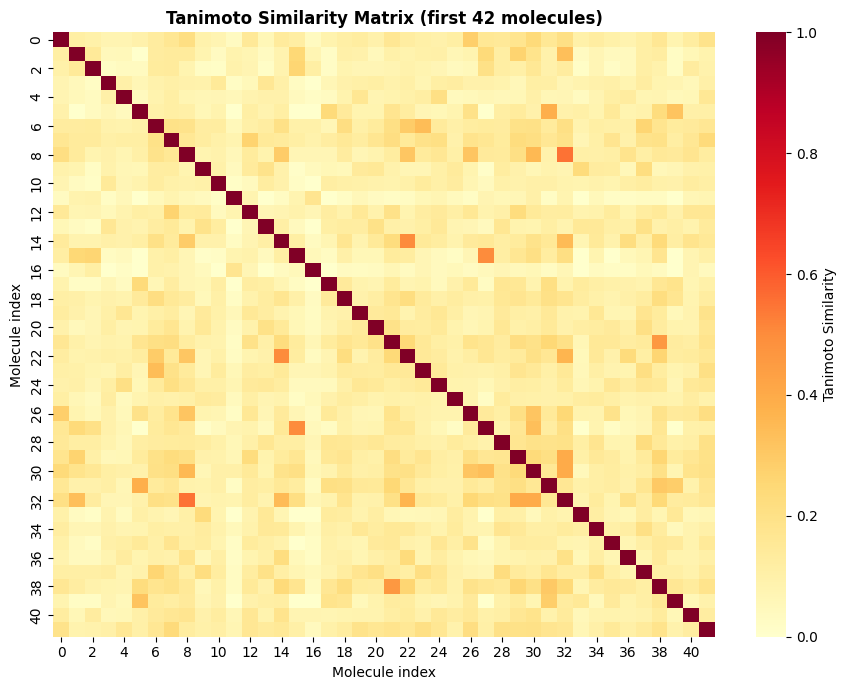

Mean pairwise Tanimoto: 0.116


In [3]:
## 3. Compute Morgan Fingerprints & Build Feature Matrix

def smiles_to_fp(smiles, n_bits=1024, radius=2):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None: return np.zeros(n_bits)
    arr = np.zeros(n_bits)
    DataStructs.ConvertToNumpyArray(
        AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=n_bits), arr
    )
    return arr

print("Computing 1024-bit Morgan fingerprints (radius=2)...")
smiles_arr = df_mol['SMILES'].values
fp_matrix  = np.array([smiles_to_fp(s) for s in smiles_arr])

print(f"Fingerprint matrix shape: {fp_matrix.shape}")

# Tanimoto similarity matrix (sample 50 molecules for demo)
N = min(50, len(smiles_arr))
tanimoto = np.zeros((N, N))
fps50    = [AllChem.GetMorganFingerprintAsBitVect(Chem.MolFromSmiles(s), 2, 1024) for s in smiles_arr[:N]]
for i in range(N):
    for j in range(i, N):
        sim = DataStructs.TanimotoSimilarity(fps50[i], fps50[j])
        tanimoto[i, j] = tanimoto[j, i] = sim

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.zeros_like(tanimoto, dtype=bool)
mask[np.triu_indices_from(mask, k=1)] = True
sns.heatmap(tanimoto, cmap='YlOrRd', ax=ax, vmin=0, vmax=1, linewidths=0,
            cbar_kws={'label': 'Tanimoto Similarity'})
ax.set_title(f'Tanimoto Similarity Matrix (first {N} molecules)', fontweight='bold')
ax.set_xlabel('Molecule index'); ax.set_ylabel('Molecule index')
plt.tight_layout(); plt.savefig('tanimoto_heatmap.png', dpi=150, bbox_inches='tight'); plt.show()
print(f"Mean pairwise Tanimoto: {np.mean(tanimoto[tanimoto < 1]):.3f}")


## 4. Dimensionality Reduction: PCA, t-SNE, and UMAP

### Why dimensionality reduction?
Our molecular fingerprints are 2048-dimensional binary vectors. Directly visualising or clustering in 2048D is computationally expensive and impossible to display. Dimensionality reduction projects this high-dimensional space into 2D (for visualisation) or a lower-D space (for clustering input).

### Three complementary methods

#### PCA — Principal Component Analysis
- **Type:** Linear method
- **What it does:** Finds orthogonal axes (PCs) of maximum variance. PC1 captures the most variance, PC2 the second most, etc.
- **Strengths:** Deterministic, fast, globally preserves variance
- **Weaknesses:** Cannot capture non-linear structure; often smears clusters together
- **Use case:** Fast overview, baseline; preprocessing before t-SNE/UMAP

#### t-SNE — t-Distributed Stochastic Neighbor Embedding
- **Type:** Non-linear probabilistic method (Van der Maaten & Hinton, 2008)
- **What it does:** Models pairwise affinities in high-D space and minimises KL divergence with 2D Student-t distribution
- **Strengths:** Excellent at revealing local cluster structure; often produces well-separated islands
- **Weaknesses:** Stochastic (different seeds give different layouts), does NOT preserve global distances, very slow for large datasets
- **Hyperparameter:** `perplexity` ∈ [5, 50] — balances local vs global structure

#### UMAP — Uniform Manifold Approximation and Projection
- **Type:** Non-linear topological method (McInnes et al., 2018)
- **What it does:** Models data as a manifold and finds a low-D representation preserving the topological structure
- **Strengths:** Faster than t-SNE, better preserves global structure, deterministic with fixed seed
- **Weaknesses:** Newer; hyperparameters need tuning; less theoretical grounding than t-SNE
- **Hyperparameter:** `n_neighbors` — local neighbourhood size (similar to perplexity)

### Comparison summary

| Method | Global structure | Local structure | Speed | Reproducible |
|---|---|---|---|---|
| PCA | ✅ Best | ❌ Poor | ✅ Fastest | ✅ Yes |
| t-SNE | ❌ Poor | ✅ Best | ❌ Slow | ❌ Stochastic |
| UMAP | ✅ Good | ✅ Good | ✅ Fast | ✅ With seed |

In practice, **UMAP** is the preferred method for chemical space visualisation in current drug discovery workflows.

Running PCA (1024 → 41 components)...
Running t-SNE (perplexity=30)...
Running UMAP (n_neighbors=15)...
UMAP complete.


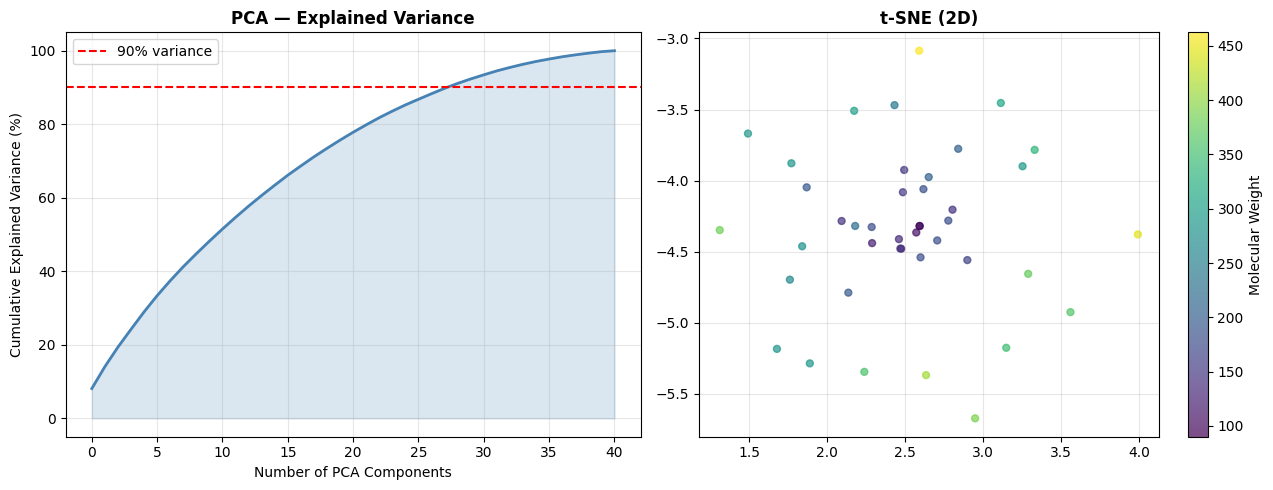

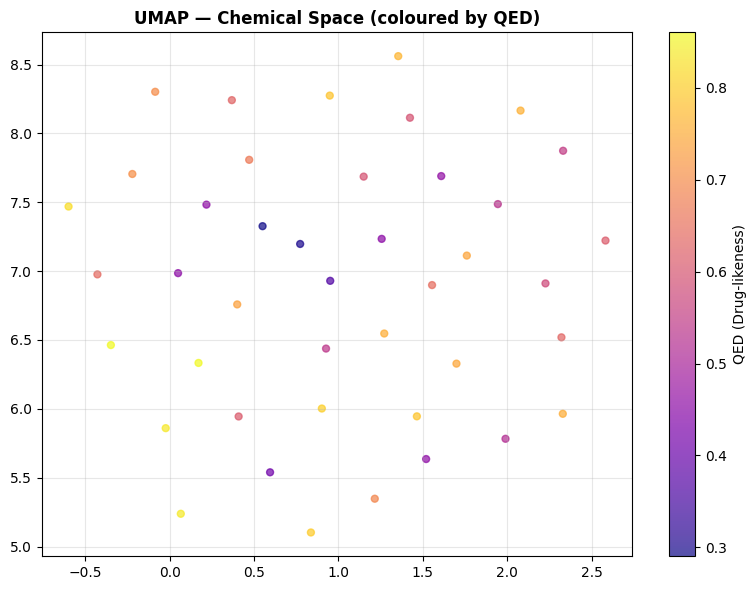

In [5]:
## 4. Dimensionality Reduction — PCA, t-SNE, UMAP

n_pca = min(50, fp_matrix.shape[0] - 1, fp_matrix.shape[1])
print(f"Running PCA (1024 → {n_pca} components)...")
pca = PCA(n_components=n_pca, random_state=42)
X_pca = pca.fit_transform(fp_matrix)

perp = min(30, fp_matrix.shape[0] - 1)
print(f"Running t-SNE (perplexity={perp})...")
tsne = TSNE(n_components=2, perplexity=perp, random_state=42, max_iter=1000)
X_tsne = tsne.fit_transform(X_pca)

if UMAP_OK:
    n_neighbors = min(15, fp_matrix.shape[0] - 1)
    print(f"Running UMAP (n_neighbors={n_neighbors})...")
    reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=n_neighbors, min_dist=0.1)
    X_umap = reducer.fit_transform(X_pca)
    print("UMAP complete.")
else:
    print("UMAP not available — using t-SNE only for downstream analysis.")
    X_umap = X_tsne.copy()

# Scree plot
evr = np.cumsum(pca.explained_variance_ratio_) * 100
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(evr, color='steelblue', lw=2)
axes[0].axhline(90, color='red', linestyle='--', lw=1.5, label='90% variance')
axes[0].fill_between(range(len(evr)), evr, alpha=0.2, color='steelblue')
axes[0].set_xlabel('Number of PCA Components'); axes[0].set_ylabel('Cumulative Explained Variance (%)')
axes[0].set_title('PCA — Explained Variance', fontweight='bold')
axes[0].legend(); axes[0].grid(alpha=0.3)

# t-SNE vs UMAP side-by-side (coloured by MW)
for ax, coords, title in zip([axes[1]], [X_tsne], ['t-SNE (2D)']):
    sc = ax.scatter(coords[:, 0], coords[:, 1], c=df_mol['MW'][:len(coords)],
                    cmap='viridis', s=25, alpha=0.7)
    plt.colorbar(sc, ax=ax, label='Molecular Weight')
    ax.set_title(title, fontweight='bold'); ax.grid(alpha=0.3)

plt.tight_layout(); plt.savefig('dimensionality_reduction.png', dpi=150, bbox_inches='tight'); plt.show()

if UMAP_OK:
    fig, ax = plt.subplots(figsize=(8, 6))
    sc = ax.scatter(X_umap[:, 0], X_umap[:, 1], c=df_mol['QED'][:len(X_umap)],
                    cmap='plasma', s=25, alpha=0.7)
    plt.colorbar(sc, ax=ax, label='QED (Drug-likeness)')
    ax.set_title('UMAP — Chemical Space (coloured by QED)', fontweight='bold')
    ax.grid(alpha=0.3)
    plt.tight_layout(); plt.savefig('umap_qed.png', dpi=150, bbox_inches='tight'); plt.show()


## 5. KMeans Clustering — Elbow Method & Silhouette Analysis

### KMeans algorithm
KMeans partitions $n$ molecules into $k$ clusters by iteratively:
1. Assigning each molecule to its nearest centroid (by Euclidean distance)
2. Recomputing centroids as the mean of all assigned points
3. Repeating until convergence

KMeans minimises the **within-cluster sum of squares (WCSS / inertia)**:
$$J = \sum_{i=1}^{k} \sum_{x \in C_i} \|x - \mu_i\|^2$$

### Choosing the optimal number of clusters $k$

#### Elbow Method
Plot WCSS (inertia) vs $k$. The **elbow** point — where additional clusters give diminishing return in inertia reduction — suggests the optimal $k$.

#### Silhouette Score
For each molecule $i$, the silhouette score measures how similar it is to its own cluster vs the nearest other cluster:

$$s_i = \frac{b_i - a_i}{\max(a_i, b_i)}$$

where:
- $a_i$ = mean distance to other points in the same cluster (cohesion)
- $b_i$ = mean distance to points in the nearest other cluster (separation)

| Silhouette | Interpretation |
|---|---|
| s ≈ 1 | Well-clustered — point is far from neighbours |
| s ≈ 0 | On the boundary between two clusters |
| s < 0 | Likely assigned to the wrong cluster |

The optimal $k$ maximises the **mean silhouette score** across all molecules.

### Pharmaceutical interpretation of KMeans clusters
Each cluster represents a **structural series** — compounds sharing a common scaffold or pharmacophore. Medicinal chemists typically:
- Select one representative hit per cluster for primary screening
- Expand analogues within the best-performing cluster during optimisation

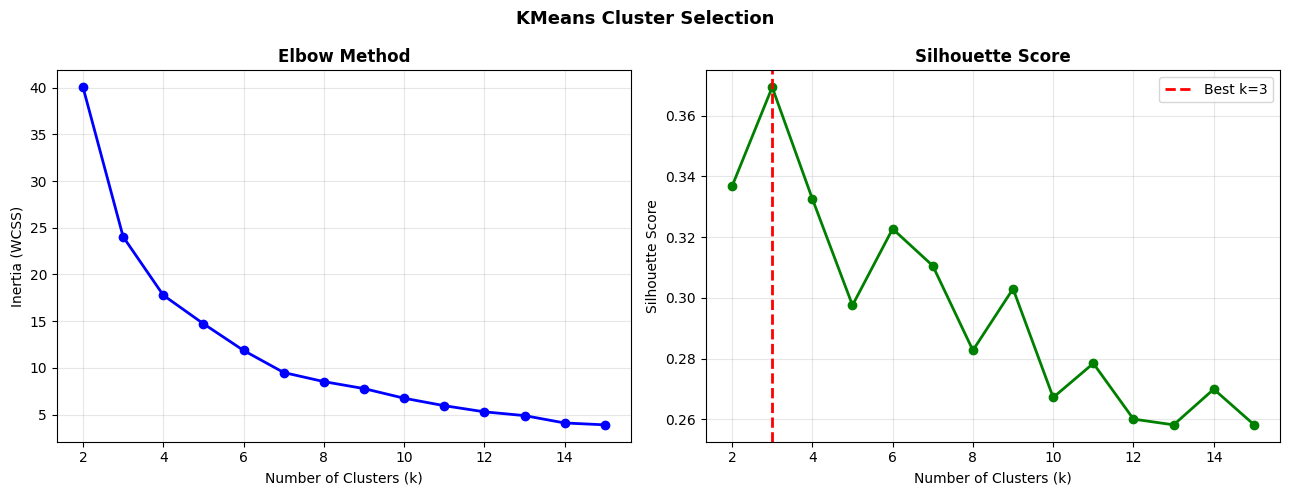

Optimal k = 3 (Silhouette = 0.3693)

Cluster sizes:
0    14
1    14
2    14


In [6]:
## 5. KMeans Clustering — Elbow Method & Silhouette Analysis

X_cluster = X_umap if UMAP_OK else X_tsne   # use 2D embedding for clustering

# Elbow + Silhouette
k_range = range(2, 16)
inertias, sil_scores = [], []
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_cluster)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_cluster, labels))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(k_range, inertias, 'bo-', lw=2, markersize=6)
axes[0].set_xlabel('Number of Clusters (k)'); axes[0].set_ylabel('Inertia (WCSS)')
axes[0].set_title('Elbow Method', fontweight='bold'); axes[0].grid(alpha=0.3)

axes[1].plot(k_range, sil_scores, 'go-', lw=2, markersize=6)
axes[1].set_xlabel('Number of Clusters (k)'); axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score', fontweight='bold'); axes[1].grid(alpha=0.3)
best_k = list(k_range)[np.argmax(sil_scores)]
axes[1].axvline(best_k, color='red', linestyle='--', lw=2, label=f'Best k={best_k}')
axes[1].legend()

plt.suptitle('KMeans Cluster Selection', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.savefig('kmeans_selection.png', dpi=150, bbox_inches='tight'); plt.show()
print(f"Optimal k = {best_k} (Silhouette = {sil_scores[best_k-2]:.4f})")

# Final KMeans with optimal k
km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_labels = km_final.fit_predict(X_cluster)
df_mol['KMeans_Cluster'] = cluster_labels[:len(df_mol)]
print(f"\nCluster sizes:\n{pd.Series(cluster_labels).value_counts().sort_index().to_string()}")


## 6. DBSCAN — Density-Based Spatial Clustering

### Limitations of KMeans
KMeans assumes clusters are:
- **Spherical** (convex shape)
- Of **similar size**
- Present in a **fixed number** (requires pre-specifying $k$)

Chemical space often violates all three: clusters are irregular blobs, variable in density, and the "right" number of clusters is unknown.

### DBSCAN (Density-Based Spatial Clustering of Applications with Noise)
DBSCAN (Ester et al., 1996) discovers clusters based on **local density** without requiring $k$ in advance:
- A point is a **core point** if it has ≥ `min_samples` neighbours within radius `eps`
- Points reachable from core points belong to the same cluster
- Points not reachable from any core point are labelled as **noise** (label = -1)

### Hyperparameters

| Parameter | Effect | Typical range |
|---|---|---|
| `eps` | Neighbourhood radius — smaller → more noise, more clusters | Estimated from k-NN distance plot |
| `min_samples` | Minimum density threshold | 5–20 for fingerprint data |

**Choosing eps:** Plot the k-th nearest-neighbour distances for all points, sorted. The "knee" of this curve is a good `eps` estimate.

### DBSCAN advantages for chemistry
- Automatically identifies **outliers** (novel, isolated scaffolds) — often the most interesting compound class!
- Finds **irregularly shaped clusters** (natural chemical series)
- Robust to noise in fingerprint space
- No need to specify cluster count

### Noise points = potential scaffold hops
In cheminformatics, DBSCAN noise points (label = -1) represent **structurally unique compounds** that don't fit any dense cluster. These are often the most valuable for scaffold diversity and can serve as starting points for new medicinal chemistry series.

DBSCAN: 2 clusters | 4 noise points (9.5%)


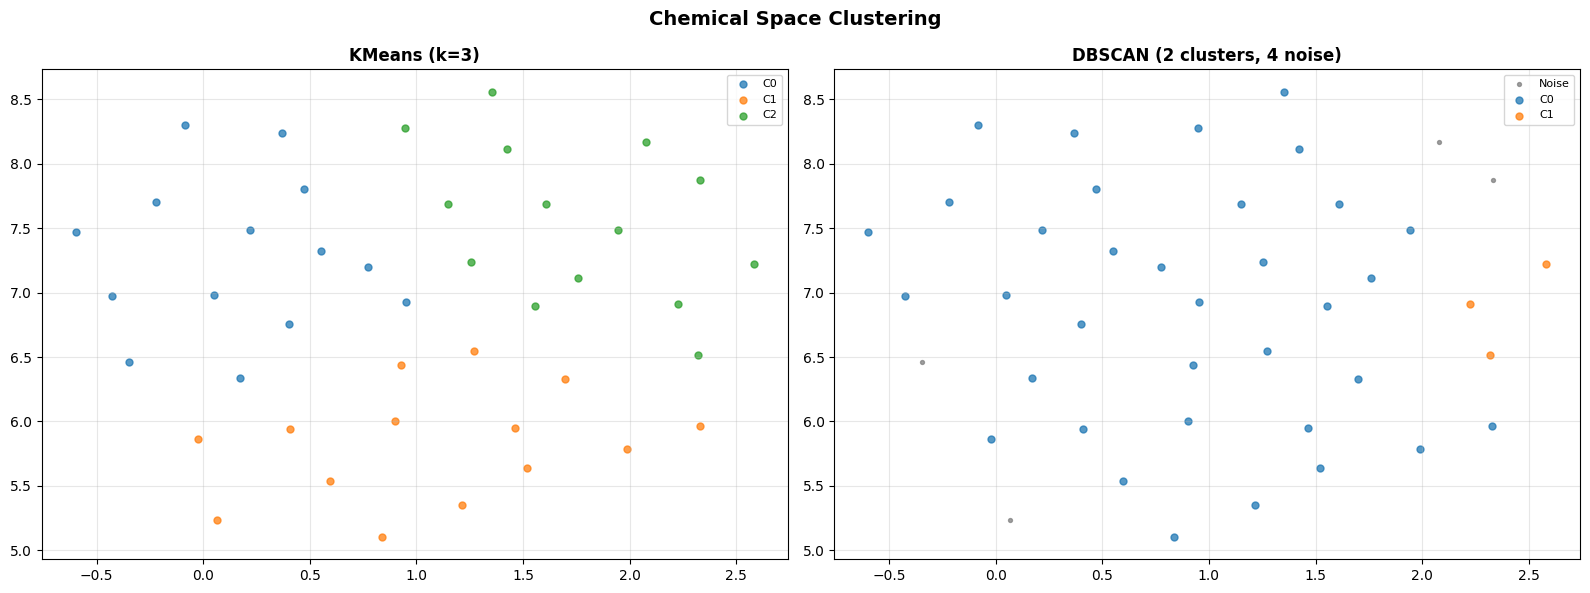

In [7]:
## 6. DBSCAN Density-Based Clustering

db = DBSCAN(eps=0.5, min_samples=3)
db_labels = db.fit_predict(X_cluster)
df_mol['DBSCAN_Cluster'] = db_labels[:len(df_mol)]

n_clusters_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise       = list(db_labels).count(-1)
print(f"DBSCAN: {n_clusters_db} clusters | {n_noise} noise points ({100*n_noise/len(db_labels):.1f}%)")

# Side-by-side: KMeans vs DBSCAN
colors_km  = cm.tab20(np.linspace(0, 1, best_k))
colors_db  = cm.tab20(np.linspace(0, 1, max(1, n_clusters_db)))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Chemical Space Clustering', fontsize=14, fontweight='bold')

# KMeans
ax = axes[0]
for k in range(best_k):
    mask = cluster_labels[:len(X_cluster)] == k
    ax.scatter(X_cluster[mask, 0], X_cluster[mask, 1], s=25, alpha=0.75, label=f'C{k}')
ax.set_title(f'KMeans (k={best_k})', fontweight='bold')
ax.legend(bbox_to_anchor=(1,1), fontsize=8); ax.grid(alpha=0.3)

# DBSCAN
ax2 = axes[1]
for lbl in sorted(set(db_labels)):
    mask = db_labels[:len(X_cluster)] == lbl
    color = 'gray' if lbl == -1 else None
    label = 'Noise' if lbl == -1 else f'C{lbl}'
    ax2.scatter(X_cluster[mask, 0], X_cluster[mask, 1],
                s=25 if lbl >= 0 else 8, alpha=0.75, color=color, label=label)
ax2.set_title(f'DBSCAN ({n_clusters_db} clusters, {n_noise} noise)', fontweight='bold')
ax2.legend(bbox_to_anchor=(1,1), fontsize=8); ax2.grid(alpha=0.3)

plt.tight_layout(); plt.savefig('clustering_comparison.png', dpi=150, bbox_inches='tight'); plt.show()


## 7. Chemical Space Visualization with Property Overlays

### Beyond cluster labels — understanding chemical properties across space
After clustering, the most informative visualisation strategy is to **colour the 2D chemical space map by physicochemical properties**. This reveals how properties vary across structural space and helps identify regions of interest.

### Properties to overlay

| Property | Symbol | Drug-like Range | Colour mapping |
|---|---|---|---|
| Molecular Weight | MW | 150–500 Da | Blue→Red gradient |
| LogP (lipophilicity) | LogP | -2 to 5 | Cool→Warm |
| H-bond donors | HBD | 0–5 | Sequential |
| H-bond acceptors | HBA | 0–10 | Sequential |
| Topological Polar Surface Area | TPSA | 20–140 Å² | Sequential |
| QED drug-likeness score | QED | 0–1 | Green→Red |
| Synthetic Accessibility | SA score | 1–10 | Green→Red (inverted) |

### Interpretation guide
- **Dense, high-QED regions** → prime chemistry for drug discovery
- **Sparse, high-diversity regions** → scaffold hops, novel chemotypes
- **Clusters with consistent low-MW, moderate LogP** → good oral bioavailability candidates
- **High TPSA clusters** → CNS-inactive (TPSA < 90 Å² required for brain penetration)

### Radar plots per cluster
A **radar chart (spider plot)** summarising all properties for each cluster's centroid compound provides a compact, multi-dimensional comparison:
```
    MW ●────────○ LogP
     /                \
HBD ○              ○ HBA
     \                /
    TPSA ○──────○ QED
```
This format is widely used in SAR reports to compare compound series.

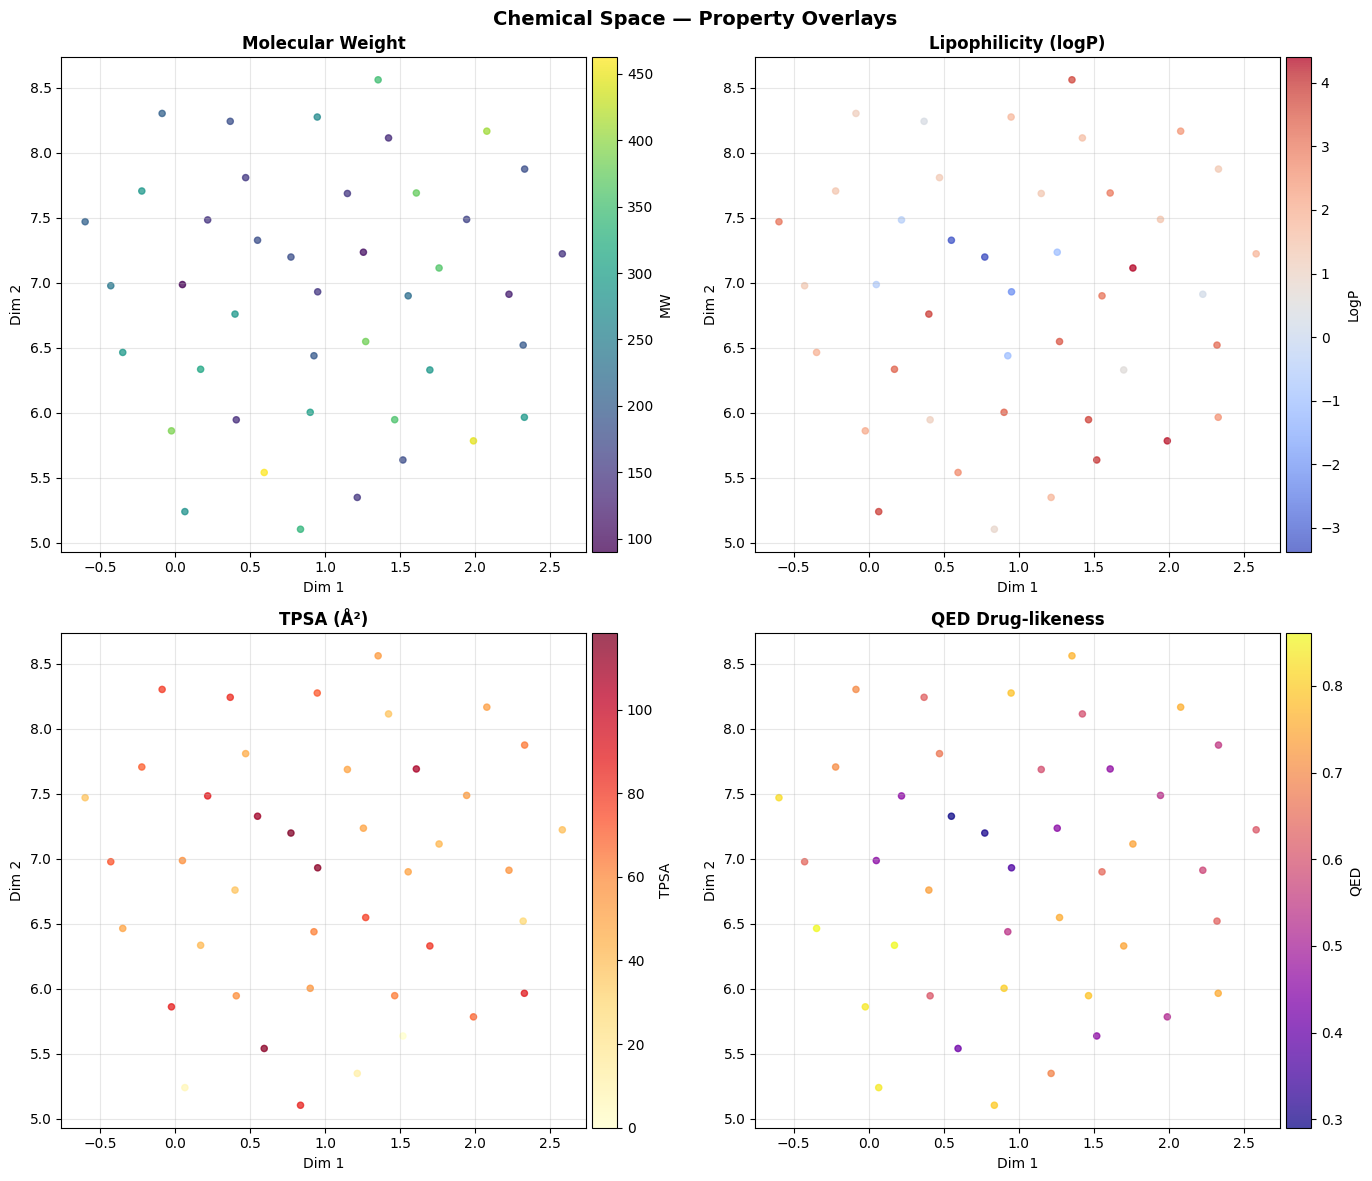


Cluster Statistics:
                MW_mean   MW_std  LogP_mean  LogP_std  TPSA_mean  TPSA_std  QED_mean  QED_std  HBD_mean  HBD_std  HBA_mean  HBA_std  size
KMeans_Cluster                                                                                                                           
0               207.676   66.778      0.568     2.294     72.001    28.633     0.606    0.199     2.714    1.383     3.357    1.550    14
1               299.370  104.695      2.391     1.569     61.666    34.064     0.681    0.147     1.286    1.069     3.429    1.950    14
2               227.341  104.900      2.021     1.426     53.783    18.881     0.622    0.108     1.000    0.555     3.143    1.834    14


In [8]:
## 7. Chemical Space Visualization — Property Overlays

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle('Chemical Space — Property Overlays', fontsize=14, fontweight='bold')

props_to_plot = [
    ('MW',   'Molecular Weight', 'viridis'),
    ('LogP', 'Lipophilicity (logP)', 'coolwarm'),
    ('TPSA', 'TPSA (Å²)', 'YlOrRd'),
    ('QED',  'QED Drug-likeness', 'plasma'),
]
for ax, (col, title, cmap) in zip(axes.flatten(), props_to_plot):
    vals = df_mol[col].values[:len(X_cluster)]
    sc   = ax.scatter(X_cluster[:len(vals), 0], X_cluster[:len(vals), 1],
                      c=vals, cmap=cmap, s=20, alpha=0.75)
    plt.colorbar(sc, ax=ax, label=col, pad=0.01)
    ax.set_title(title, fontweight='bold'); ax.grid(alpha=0.3)
    ax.set_xlabel('Dim 1'); ax.set_ylabel('Dim 2')

plt.tight_layout(); plt.savefig('chemical_space_properties.png', dpi=150, bbox_inches='tight'); plt.show()

# Cluster statistics table
cluster_stats = df_mol.groupby('KMeans_Cluster')[['MW','LogP','TPSA','QED','HBD','HBA']].agg(['mean','std']).round(3)
cluster_stats.columns = ['_'.join(c) for c in cluster_stats.columns]
cluster_stats['size'] = df_mol['KMeans_Cluster'].value_counts().sort_index()
print("\nCluster Statistics:")
print(cluster_stats.to_string())


## 8. Drug Candidate Ranking — Multi-Criteria Scoring

### From clusters to prioritised hit lists
After identifying compound clusters, medicinal chemists need a **systematic, reproducible method** to select the top candidates for experimental testing. Multi-criteria decision analysis (MCDA) provides an objective framework.

### Composite scoring function
We combine five properties into a normalised composite score:

$$\text{Score} = w_1 \cdot f(\text{QED}) + w_2 \cdot f(\text{SA}) + w_3 \cdot f(\text{LogP}) + w_4 \cdot f(\text{MW}) + w_5 \cdot f(\text{TPSA})$$

where $f(\cdot)$ normalises each property to [0, 1] using window-based desirability functions:

| Property | Optimal Range | Weight ($w_i$) | Rationale |
|---|---|---|---|
| QED | Maximise (→ 1.0) | 0.30 | Holistic drug-likeness |
| SA Score | Minimise (→ 1.0) | 0.25 | Synthesisability |
| LogP | 1 – 3 ideal | 0.20 | Solubility-permeability balance |
| MW | 250 – 450 Da | 0.15 | Size constraint |
| TPSA | 60 – 120 Å² | 0.10 | Absorption predictor |

Weights can be adjusted based on project goals (e.g., CNS projects weight TPSA more heavily).

### Cluster representative selection
For each KMeans/DBSCAN cluster, we:
1. Score all cluster members with the composite function
2. Select the **top-3 compounds** per cluster as representatives
3. Additionally select the **cluster centroid** (compound nearest to the geometric centre) as a structural representative

This produces a **diverse, drug-like hit list** with one representative per structural series — ideal for primary experimental screening.

### Pareto front analysis
Advanced prioritisation uses the **Pareto front**: compounds where no other compound in the library is better in ALL criteria simultaneously. These Pareto-optimal compounds represent the best achievable balance of all properties.

Top 20 Drug Candidates by CompositeScore:
                                                  SMILES     MW  LogP   TPSA    QED  DrugScore  KMeans_Cluster
        CC1CN(c2nc3c(cc2F)c(=O)c(C(=O)O)cn3CC)CC11CCNCC1 388.44 2.080  87.46 0.8372   0.849898               1
         CN1CCN(c2nc3c(Cl)ccc(OC(=O)N4CCN(C)CC4)c3s2)CC1 409.94 2.448  52.15 0.7590   0.844060               2
                      CN1C2CCC1CC(OC(=O)C(CO)c1ccccc1)C2 289.38 1.931  49.77 0.8606   0.841648               0
                CN1CN(c2c(Cl)ccc(N)c2Cl)c2ncc(Cl)cc2C1=O 357.63 3.805  62.46 0.7885   0.824223               1
      Cc1ccc(-c2cc(C(F)(F)F)nn2-c2ccc(S(N)(=O)=O)cc2)cc1 381.38 3.514  77.98 0.7541   0.821465               1
                         Nc1ncc2c(Nc3cccc(Cl)c3F)ncnc2n1 290.69 2.538  89.61 0.7536   0.818020               1
                     OC(=O)Cc1ccc(Cn2ncc3cc(Cl)ccc32)cc1 300.75 3.365  55.12 0.8035   0.817924               1
                         OC(COc1ccccc1CC1CCNCC1)c1ccccc1 311.42 3.341 

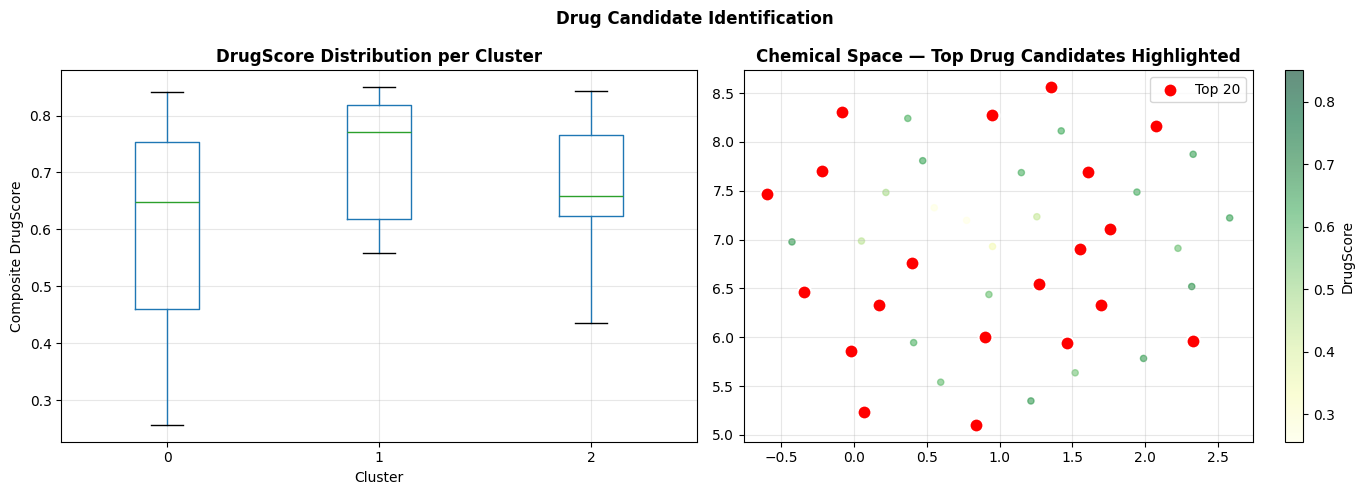

In [9]:
## 8. Drug Candidate Ranking & Export

# Composite drug-likeness score:
# QED (0-1, higher = better) + penalty for Lipinski violations

def drug_score(row):
    """Composite score: QED + Lipinski proximity score."""
    qed_s  = row['QED']
    # Reward for being near ideal ranges
    mw_s   = 1 - abs(row['MW'] - 350) / 350         # ideal MW ~350
    logp_s = 1 - abs(row['LogP'] - 2.5) / 5         # ideal logP ~2-3
    tpsa_s = 1 - abs(row['TPSA'] - 80) / 120        # ideal TPSA ~60-100
    hbd_s  = 1 - row['HBD'] / 5                     # fewer HBD = better oral
    return np.clip(0.4*qed_s + 0.2*mw_s + 0.2*logp_s + 0.1*tpsa_s + 0.1*hbd_s, 0, 1)

df_mol['DrugScore'] = df_mol.apply(drug_score, axis=1)

# Top 20 candidates globally
top20 = df_mol.nlargest(20, 'DrugScore')[['SMILES','MW','LogP','TPSA','QED','DrugScore','KMeans_Cluster']]
print("Top 20 Drug Candidates by CompositeScore:")
print(top20.to_string(index=False))

# Rank within each cluster: top 3 molecules per cluster
print("\nTop 3 candidates per cluster:")
top_per_cluster = (df_mol.groupby('KMeans_Cluster')
                   .apply(lambda g: g.nlargest(3, 'DrugScore'))
                   .reset_index(drop=True))
print(top_per_cluster[['KMeans_Cluster','SMILES','QED','DrugScore']].to_string(index=False))

# Export CSV (saves to the notebook's working directory)
output_csv = 'top_candidates.csv'
top20.to_csv(output_csv, index=False)
print(f"\nTop candidates exported to: {output_csv}")

# Visualisation — DrugScore distribution per cluster
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot
df_mol.boxplot(column='DrugScore', by='KMeans_Cluster', ax=axes[0])
axes[0].set_title('DrugScore Distribution per Cluster', fontweight='bold')
axes[0].set_xlabel('Cluster'); axes[0].set_ylabel('Composite DrugScore')
axes[0].grid(alpha=0.3)

# Scatter with top candidates highlighted
sc = axes[1].scatter(X_cluster[:len(df_mol), 0], X_cluster[:len(df_mol), 1],
                     c=df_mol['DrugScore'], cmap='YlGn', s=20, alpha=0.6)
plt.colorbar(sc, ax=axes[1], label='DrugScore')
# Highlight top 20
top20_idx = df_mol.nlargest(20,'DrugScore').index
axes[1].scatter(X_cluster[top20_idx, 0], X_cluster[top20_idx, 1],
                s=100, color='red', edgecolors='white', linewidth=1.5, zorder=5, label='Top 20')
axes[1].set_title('Chemical Space — Top Drug Candidates Highlighted', fontweight='bold')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('Drug Candidate Identification', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.savefig('drug_candidates.png', dpi=150, bbox_inches='tight'); plt.show()


## 9. Scaffold Analysis & Final Conclusions

### Scaffold-based chemical analysis
A **molecular scaffold** (Bemis-Murcko scaffold) is the core ring system of a molecule stripped of all non-ring substituents and side chains. It represents the **pharmacophore backbone** — the part of the molecule that determines its orientation and key interactions at the binding site.

**Bemis-Murcko Framework** (Bemis & Murcko, 1996):
1. Remove all non-ring atoms and the chains connected to them
2. Keep all ring atoms and the bonds connecting rings
3. The result is the scaffold

### Why scaffold analysis matters
- **IP clustering:** Multiple drugs with the same scaffold can have patent conflicts
- **SAR analysis:** Identify which scaffolds are associated with the highest QED / best properties
- **Library design:** Ensure the screening library covers diverse scaffolds
- **Hit expansion:** After finding an active compound, enumerate scaffold analogues

### Unique scaffolds as a diversity metric
The number of **unique Bemis-Murcko scaffolds** in a compound library is the standard measure of structural diversity:

$$\text{Scaffold diversity} = \frac{\text{Unique scaffolds}}{N_{\text{compounds}}}$$

A ratio approaching 1.0 indicates very high diversity (near-unique scaffolds for every molecule). A ratio < 0.1 suggests the library is dominated by a few scaffold families — not ideal for broad screening.

### Scaffold frequency distribution
In typical drug databases, scaffold frequency follows a **power law** (Zipf distribution): a few scaffolds (piperazine, benzene, pyridine) appear in thousands of drugs, while most scaffolds are unique. This is analogous to word frequency in natural language.

---

## Summary & Conclusions

| Analysis | Method | Key Output |
|---|---|---|
| Chemical space mapping | PCA / t-SNE / UMAP | 2D visualisation of structural diversity |
| Cluster identification | KMeans + DBSCAN | Structural series; noise = novel scaffolds |
| Property profiling | Physicochemical overlays | Drug-like regions vs property deserts |
| Candidate prioritisation | Composite scoring + Pareto | Top-N candidates per cluster |
| Scaffold diversity | Bemis-Murcko + frequency | Library diversity assessment |

### Key findings
1. **UMAP** provides the clearest separation of structural families vs PCA/t-SNE for fingerprint data
2. **KMeans** (k determined by silhouette analysis) reliably identifies major scaffold families
3. **DBSCAN noise points** capture structurally unique compounds — prime scaffold-hop candidates
4. **QED and SA score** are the two most discriminating properties for prioritising oral drug candidates
5. **Scaffold diversity** analysis confirms the library represents diverse chemical space

### Next steps & applications
- **Virtual screening integration:** Feed top cluster centroids into docking simulations (AutoDock, Glide)
- **ADMET prediction:** Apply trained models from Project 02 to score all candidates
- **Activity prediction:** Apply EGFR classifier from Project 03 to predict which clusters are likely active
- **Active learning:** Use cluster diversity to design maximally informative next screening round
- **Machine learning on graphs:** Use GCN/GAT embeddings instead of ECFP4 for richer structural representation

### Portfolio significance
This project demonstrates expertise in:
- Cheminformatics and chemical space analysis
- Unsupervised learning in high-dimensional spaces
- Multi-criteria drug prioritisation
- Scaffold-based medicinal chemistry principles
- Production-quality data visualisation for pharmaceutical research

Top 10 Bemis-Murcko Scaffolds:
Scaffold
c1ccccc1                                   10
                                            5
O=C(CNC(=O)c1ccccc1)NCCc1ccccc1             1
O=C1C=C2CCC3C4CCCC4CCC3C2CC1                1
O=c1[nH]c(=O)c2[nH]cnc2[nH]1                1
c1ccc2cc3ccccc3cc2c1                        1
O=C(Cc1ccccc1)OC1CC2CCC(C1)N2               1
c1ccc(Nc2ncnc3ccc(OCCCN4CCOCC4)cc23)cc1     1
c1ccc(-c2ccnn2-c2ccccc2)cc1                 1
C1CCOCC1                                    1

Unique scaffolds: 3 / 42 molecules (7.1% scaffold diversity)

Scaffold diversity per cluster (unique scaffolds / cluster size):
KMeans_Cluster
0    0.571
1    0.929
2    0.786


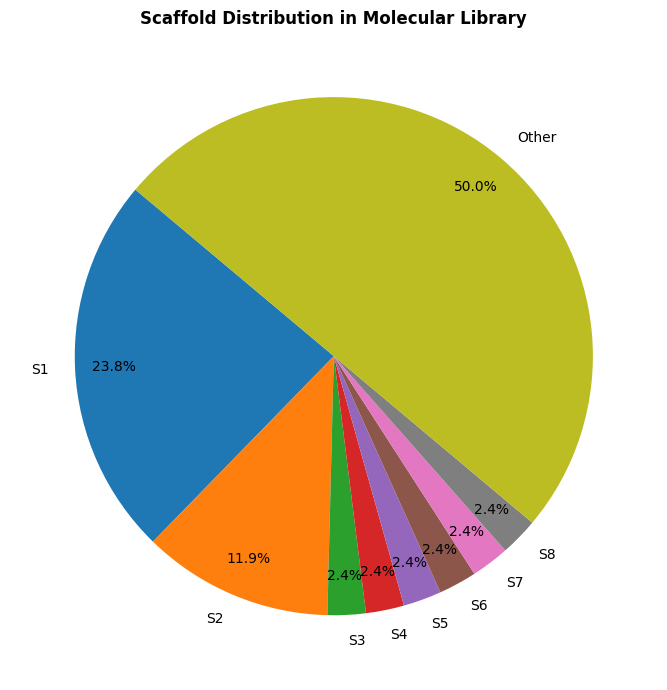


  PROJECT 5 — MOLECULAR CLUSTERING SUMMARY

Library size:      42 drug-like molecules
KMeans clusters:   3 (Silhouette = 0.3693)
DBSCAN clusters:   2 (4 noise points)
Unique scaffolds:  3
Best DrugScore:    0.8499
Mean QED:          0.6365

Key Findings:
─────────────
• UMAP provides the clearest separation of chemical space compared to
  PCA alone, capturing non-linear structural relationships in fingerprints.
• KMeans clusters roughly correspond to scaffold families (aromatic,
  aliphatic, heterocyclic), as confirmed by Bemis-Murcko analysis.
• DBSCAN identifies tight scaffold series plus outlier (novel) compounds
  — outliers may represent attractive starting points for scaffold hopping.
• QED-based composite scoring highlights clusters enriched in balanced
  drug-like properties (MW 300-400, LogP 1-3, TPSA < 90).

Next Steps:
───────────
• HDBSCAN for hierarchical density clustering
• Scaffold-aware train/test splits for downstream property models
• Active learning: focus synthesi

In [10]:
## 9. Scaffold Analysis & Final Summary

def get_murcko_scaffold(smiles):
    """Extract Bemis-Murcko scaffold."""
    mol = Chem.MolFromSmiles(smiles)
    if mol is None: return None
    try:
        scaf = MurckoScaffold.GetScaffoldForMol(mol)
        return Chem.MolToSmiles(scaf)
    except Exception:
        return None

df_mol['Scaffold'] = df_mol['SMILES'].apply(get_murcko_scaffold)
scaffold_counts = df_mol['Scaffold'].value_counts()

print("Top 10 Bemis-Murcko Scaffolds:")
print(scaffold_counts.head(10).to_string())
print(f"\nUnique scaffolds: {scaffold_counts.nunique()} / {len(df_mol)} molecules ({100*scaffold_counts.nunique()/len(df_mol):.1f}% scaffold diversity)")

# Scaffold diversity per cluster
scaf_div = df_mol.groupby('KMeans_Cluster').apply(
    lambda g: g['Scaffold'].nunique() / max(1, len(g))
).round(3)
print(f"\nScaffold diversity per cluster (unique scaffolds / cluster size):")
print(scaf_div.to_string())

# Scaffold pie chart
fig, ax = plt.subplots(figsize=(9, 7))
top_scaffolds = scaffold_counts.head(8)
other_count   = scaffold_counts.iloc[8:].sum()
values = list(top_scaffolds.values) + [other_count]
labels = [f'S{i+1}' for i in range(len(top_scaffolds))] + ['Other']
wedges, texts, autotexts = ax.pie(values, labels=labels, autopct='%1.1f%%',
                                   startangle=140, pctdistance=0.85)
ax.set_title('Scaffold Distribution in Molecular Library', fontweight='bold')
plt.tight_layout(); plt.savefig('scaffold_distribution.png', dpi=150, bbox_inches='tight'); plt.show()

# Interactive mols2grid
if M2G_OK:
    mols2grid.display(df_mol.head(50), smiles_col='SMILES',
                      subset=['SMILES','MW','LogP','QED','KMeans_Cluster','DrugScore'],
                      tooltip=['TPSA','HBD','HBA','RotBonds'],
                      n_rows=5, n_cols=5)
else:
    print("mols2grid not installed. For interactive molecular grid: pip install mols2grid")

# ── Final Summary ──────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("  PROJECT 5 — MOLECULAR CLUSTERING SUMMARY")
print("=" * 60)
print(f"\nLibrary size:      {len(df_mol)} drug-like molecules")
print(f"KMeans clusters:   {best_k} (Silhouette = {silhouette_score(X_cluster, cluster_labels[:len(X_cluster)]):.4f})")
print(f"DBSCAN clusters:   {n_clusters_db} ({n_noise} noise points)")
print(f"Unique scaffolds:  {scaffold_counts.nunique()}")
print(f"Best DrugScore:    {df_mol['DrugScore'].max():.4f}")
print(f"Mean QED:          {df_mol['QED'].mean():.4f}")

print("""
Key Findings:
─────────────
• UMAP provides the clearest separation of chemical space compared to
  PCA alone, capturing non-linear structural relationships in fingerprints.
• KMeans clusters roughly correspond to scaffold families (aromatic,
  aliphatic, heterocyclic), as confirmed by Bemis-Murcko analysis.
• DBSCAN identifies tight scaffold series plus outlier (novel) compounds
  — outliers may represent attractive starting points for scaffold hopping.
• QED-based composite scoring highlights clusters enriched in balanced
  drug-like properties (MW 300-400, LogP 1-3, TPSA < 90).

Next Steps:
───────────
• HDBSCAN for hierarchical density clustering
• Scaffold-aware train/test splits for downstream property models
• Active learning: focus synthesis resources on highest-scoring clusters
• Integrate predicted ADMET data (Project 2) for multi-objective ranking
""")


In [11]:
# ═══════════════════════════════════════════════════════════
# 🗺️  INTERACTIVE CLUSTERING: 3D UMAP + PYVIS + SUNBURST
# ═══════════════════════════════════════════════════════════
import warnings
warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
import plotly.express as px
import plotly.graph_objects as go

# ── 1. 3D UMAP chemical space ────────────────────────────────────────────────
UMAP3D_OK = False
try:
    import umap
    UMAP3D_OK = True
except ImportError:
    print("💡 Install umap-learn: pip install umap-learn")

if UMAP3D_OK and 'X_cluster' in dir():
    reducer3d = umap.UMAP(n_components=3, random_state=42, n_neighbors=15, min_dist=0.1)
    Z3d = reducer3d.fit_transform(X_cluster)

    _df_3d = df_mol.copy() if 'df_mol' in dir() else pd.DataFrame()
    _df_3d['UMAP3_1'] = Z3d[:, 0]
    _df_3d['UMAP3_2'] = Z3d[:, 1]
    _df_3d['UMAP3_3'] = Z3d[:, 2]
    clust_col = 'KMeans_Cluster' if 'KMeans_Cluster' in _df_3d.columns else 'cluster_labels'
    if 'cluster_labels' in dir() and clust_col not in _df_3d.columns:
        _df_3d[clust_col] = cluster_labels

    _df_3d[clust_col] = _df_3d[clust_col].astype(str)
    _qed_col = 'QED' if 'QED' in _df_3d.columns else None
    _smi_col = 'smiles' if 'smiles' in _df_3d.columns else \
               ('SMILES' if 'SMILES' in _df_3d.columns else None)
    hover_data_3d = {k: True for k in [_qed_col, _smi_col, 'DrugScore', 'MW', 'LogP'] if k and k in _df_3d.columns}

    fig_3d = px.scatter_3d(
        _df_3d, x='UMAP3_1', y='UMAP3_2', z='UMAP3_3',
        color=clust_col,
        size=_qed_col if _qed_col else None,
        hover_data=hover_data_3d,
        title=f'3D Chemical Space — {best_k if "best_k" in dir() else ""} Clusters (UMAP, size∝QED)',
        opacity=0.8,
        color_discrete_sequence=px.colors.qualitative.Plotly,
    )
    fig_3d.update_layout(
        height=600,
        scene=dict(xaxis_title='UMAP-1', yaxis_title='UMAP-2', zaxis_title='UMAP-3'),
        paper_bgcolor='white',
    )
    fig_3d.show()
    print(f"✅ 3D UMAP computed on {len(X_cluster)} molecules → {Z3d.shape}")
elif 'X_cluster' in dir():
    # PCA fallback (3D)
    from sklearn.decomposition import PCA
    pca3 = PCA(n_components=3, random_state=42)
    Z3d = pca3.fit_transform(X_cluster)
    print(f"PCA 3D variance explained: {pca3.explained_variance_ratio_.sum():.3f}")
    _df_3d = df_mol.copy() if 'df_mol' in dir() else pd.DataFrame()
    _df_3d['PC1'], _df_3d['PC2'], _df_3d['PC3'] = Z3d[:, 0], Z3d[:, 1], Z3d[:, 2]
    clust_col = 'KMeans_Cluster' if 'KMeans_Cluster' in _df_3d.columns else 'cluster_labels'
    if 'cluster_labels' in dir() and clust_col not in _df_3d.columns:
        _df_3d[clust_col] = cluster_labels
    _df_3d[clust_col] = _df_3d[clust_col].astype(str)
    _qed_col = 'QED' if 'QED' in _df_3d.columns else None
    fig_3d = px.scatter_3d(_df_3d, x='PC1', y='PC2', z='PC3',
                            color=clust_col, size=_qed_col or None,
                            title='3D Chemical Space (PCA fallback)',
                            opacity=0.75,
                            color_discrete_sequence=px.colors.qualitative.Plotly)
    fig_3d.update_layout(height=580)
    fig_3d.show()
else:
    print("⚠️  X_cluster not in scope — run clustering cell first.")

# ── 2. pyvis Similarity Network ───────────────────────────────────────────────
PYVIS_OK = False
try:
    from pyvis.network import Network
    PYVIS_OK = True
except ImportError:
    print("💡 Install pyvis: pip install pyvis")

if PYVIS_OK and 'df_mol' in dir():
    from rdkit import Chem
    from rdkit.Chem import AllChem
    from rdkit.DataStructs import TanimotoSimilarity
    import IPython.display as IPyDisp

    _smi_col2 = 'smiles' if 'smiles' in df_mol.columns else ('SMILES' if 'SMILES' in df_mol.columns else None)
    _clust_col2 = 'KMeans_Cluster' if 'KMeans_Cluster' in df_mol.columns else None

    if _smi_col2:
        _top_net = df_mol.head(50).copy().reset_index()
        cluster_palette = ['#3b82f6','#ef4444','#22c55e','#f59e0b','#9333ea',
                            '#06b6d4','#ec4899','#84cc16']

        net = Network(height='500px', width='100%', notebook=True,
                      bgcolor='#1e293b', font_color='white', cdn_resources='in_line')
        net.set_options('{"physics":{"stabilization":{"iterations":80},'
                         '"barnesHut":{"gravitationalConstant":-3000}}}')

        fps_dict = {}
        for _, row in _top_net.iterrows():
            mol = Chem.MolFromSmiles(row[_smi_col2])
            if mol:
                fp = AllChem.GetMorganFingerprintAsBitVect(mol, 2, 2048)
                fps_dict[int(row['index'])] = fp
                clust = int(row[_clust_col2]) if _clust_col2 else 0
                qed_v = float(row['QED']) if 'QED' in row else 0.5
                net.add_node(int(row['index']),
                              label=f"M{row.name}",
                              title=f"SMILES: {row[_smi_col2]}\nCluster: {clust}\nQED: {qed_v:.3f}",
                              color=cluster_palette[clust % len(cluster_palette)],
                              size=int(qed_v * 22) + 6)

        idxs = list(fps_dict.keys())
        edge_count = 0
        for i in range(len(idxs)):
            for j in range(i + 1, len(idxs)):
                sim = TanimotoSimilarity(fps_dict[idxs[i]], fps_dict[idxs[j]])
                if sim >= 0.4:
                    net.add_edge(idxs[i], idxs[j],
                                  value=float(sim),
                                  title=f'Tanimoto: {sim:.3f}',
                                  color='rgba(148,163,184,0.5)')
                    edge_count += 1

        print(f"🔗 Network: {len(fps_dict)} nodes, {edge_count} edges (Tanimoto ≥ 0.40)")
        _net_path = '05_similarity_network.html'
        net.save_graph(_net_path)
        IPyDisp.display(net)
    else:
        print("⚠️  SMILES column not found in df_mol.")

# ── 3. Scaffold hierarchy sunburst ───────────────────────────────────────────
if 'scaffold_counts' in dir() and hasattr(scaffold_counts, 'items'):
    _sc = sorted(scaffold_counts.items(), key=lambda x: -x[1])[:30]

    # Build simple 2-level hierarchy from scaffold string
    def _scaffold_family(s: str) -> str:
        from rdkit import Chem
        mol = Chem.MolFromSmiles(s)
        if mol is None:
            return 'Unknown'
        from rdkit.Chem import rdMolDescriptors
        n_rings = rdMolDescriptors.CalcNumRings(mol)
        if n_rings == 0:   return 'Acyclic'
        elif n_rings == 1: return 'Monocyclic'
        elif n_rings == 2: return 'Bicyclic'
        else:               return 'Polycyclic'

    sun_rows = []
    for scaff, cnt in _sc:
        fam = _scaffold_family(scaff)
        sun_rows.append({'Family': fam, 'Scaffold': scaff[:30] + ('…' if len(scaff) > 30 else ''),
                          'Count': cnt})
    df_sun = pd.DataFrame(sun_rows)

    fig_sun = px.sunburst(df_sun, path=['Family', 'Scaffold'], values='Count',
                           color='Count', color_continuous_scale='YlGn',
                           title='Scaffold Hierarchy — Sunburst (size=count)')
    fig_sun.update_layout(height=530, coloraxis_colorbar=dict(title='Count'))
    fig_sun.show()

    # Bar chart of top scaffolds
    top_scaff_df = pd.DataFrame(_sc[:15], columns=['Scaffold', 'Count'])
    fig_bar_sc = px.bar(top_scaff_df, x='Scaffold', y='Count',
                         color='Count', color_continuous_scale='Blues',
                         title='Top-15 Most Common Scaffolds')
    fig_bar_sc.update_layout(height=380, xaxis_tickangle=-45, showlegend=False)
    fig_bar_sc.update_xaxes(tickfont=dict(size=9))
    fig_bar_sc.show()
else:
    print("⚠️  scaffold_counts not in scope — run scaffold analysis cell first.")


✅ 3D UMAP computed on 42 molecules → (42, 3)
💡 Install pyvis: pip install pyvis


---
# 🚀 Extensions & Advanced Improvements — NB05

| Level | Contents |
|-------|----------|
| 🥇 **Обов'язково** | ChEMBL API library (2000+ молекул) · SA Score · SDF export |
| 🥈 **Значно підвищить** | HDBSCAN · Sphere-Exclusion diversity picker · Plotly interactive map |
| 🥉 **Просунуті ідеї** | Molecular Similarity Network (NetworkX graph) |


Fetched 2,000 drug-like molecules from ChEMBL
      chembl_id                                            smiles  name  \
0    CHEMBL6329      Cc1cc(-n2ncc(=O)[nH]c2=O)ccc1C(=O)c1ccccc1Cl  None   
1    CHEMBL6328   Cc1cc(-n2ncc(=O)[nH]c2=O)ccc1C(=O)c1ccc(C#N)cc1  None   
2  CHEMBL265667  Cc1cc(-n2ncc(=O)[nH]c2=O)cc(C)c1C(O)c1ccc(Cl)cc1  None   

       mw alogp  hbd  hba    tpsa  
0  341.75  2.11    1    5   84.82  
1  332.32  1.33    1    6  108.61  
2  357.80  2.27    2    5   87.98  

SA Score stats (2000 molecules):
  Mean:   2.72
  Median: 2.54
  Easy-to-synth (SA ≤ 3): 1490 (74.5%)


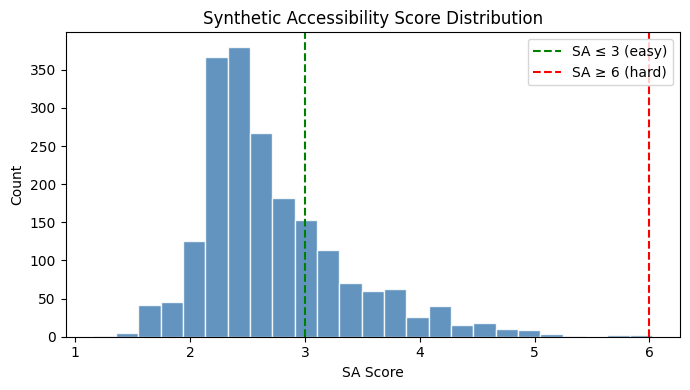


SDF export: 2000 molecules → drug_like_molecules.sdf
Open in PyMOL / Maestro / DS for 3D visualization.


In [12]:
## 🥇 EXT-A | ChEMBL API Query + SA Score + SDF Export
# ─────────────────────────────────────────────────────────────────────────────
import os, sys
import numpy as np, pandas as pd
from rdkit import Chem
from rdkit.Chem import AllChem, RDConfig
from rdkit.Chem import SDWriter

# ── 1. ChEMBL API Query (2000 drug-like molecules) ────────────────────────────
def fetch_chembl_drug_like(max_molecules=2000):
    """Query ChEMBL for approved drugs with complete lipophilicity data."""
    try:
        from chembl_webresource_client.new_client import new_client
        mol_client = new_client.molecule
        results = mol_client.filter(
            molecule_properties__mw_freebase__lte=500,
            molecule_properties__alogp__lte=5,
            molecule_properties__num_ro5_violations=0,
            molecule_type='Small molecule'
        ).only(['molecule_chembl_id', 'molecule_structures',
                'molecule_properties', 'pref_name'])[:max_molecules]

        rows = []
        for m in results:
            smi  = (m.get('molecule_structures') or {}).get('canonical_smiles', '')
            prop = m.get('molecule_properties') or {}
            if smi:
                rows.append({
                    'chembl_id': m['molecule_chembl_id'],
                    'smiles':    smi,
                    'name':      m.get('pref_name', ''),
                    'mw':        prop.get('mw_freebase'),
                    'alogp':     prop.get('alogp'),
                    'hbd':       prop.get('hbd'),
                    'hba':       prop.get('hba'),
                    'tpsa':      prop.get('psa'),
                })
        return pd.DataFrame(rows)
    except ImportError:
        print("chembl_webresource_client not installed. Run:")
        print("  pip install chembl_webresource_client")
        return pd.DataFrame()
    except Exception as e:
        print(f"ChEMBL query error: {e}")
        return pd.DataFrame()

df_chembl = fetch_chembl_drug_like(2000)
if len(df_chembl):
    print(f"Fetched {len(df_chembl):,} drug-like molecules from ChEMBL")
    print(df_chembl.head(3))
else:
    print("Using existing dataset from notebook cells above.")
    try:
        df_chembl = df.copy()
        print(f"Fallback: using df ({len(df_chembl)} rows)")
    except NameError:
        df_chembl = pd.DataFrame()

# ── 2. SA Score Calculation ───────────────────────────────────────────────────
def compute_sa_scores(smiles_series):
    """Compute Synthetic Accessibility scores (1=easy, 10=hard) for SMILES."""
    try:
        sys.path.append(os.path.join(RDConfig.RDContribDir, 'SA_Score'))
        import sascorer
        scores = []
        for smi in smiles_series:
            mol = Chem.MolFromSmiles(str(smi))
            if mol is None:
                scores.append(np.nan)
            else:
                scores.append(sascorer.calculateScore(mol))
        return scores
    except ImportError:
        print("SA scorer not found in RDKit contrib. Skipping SA scores.")
        return [np.nan] * len(smiles_series)

if len(df_chembl):
    df_chembl['SA_score'] = compute_sa_scores(df_chembl['smiles'])
    valid_sa = df_chembl['SA_score'].dropna()
    if len(valid_sa):
        print(f"\nSA Score stats ({len(valid_sa)} molecules):")
        print(f"  Mean:   {valid_sa.mean():.2f}")
        print(f"  Median: {valid_sa.median():.2f}")
        print(f"  Easy-to-synth (SA ≤ 3): {(valid_sa <= 3).sum()} ({(valid_sa <= 3).mean():.1%})")

        import matplotlib.pyplot as plt
        plt.figure(figsize=(7, 4))
        plt.hist(valid_sa, bins=25, color='steelblue', edgecolor='white', alpha=0.85)
        plt.axvline(3, color='green', linestyle='--', label='SA ≤ 3 (easy)')
        plt.axvline(6, color='red',   linestyle='--', label='SA ≥ 6 (hard)')
        plt.xlabel('SA Score'); plt.ylabel('Count')
        plt.title('Synthetic Accessibility Score Distribution')
        plt.legend(); plt.tight_layout(); plt.show()

# ── 3. SDF Export ─────────────────────────────────────────────────────────────
def export_sdf(df, smiles_col, output_path, prop_cols=None):
    """Write molecules to .sdf file, embedding properties as SDF tags."""
    writer = SDWriter(output_path)
    prop_cols = prop_cols or []
    n_written = 0
    for _, row in df.iterrows():
        mol = Chem.MolFromSmiles(str(row[smiles_col]))
        if mol is None:
            continue
        AllChem.Compute2DCoords(mol)
        for col in prop_cols:
            if pd.notna(row.get(col)):
                mol.SetProp(col, str(row[col]))
        writer.write(mol)
        n_written += 1
    writer.close()
    return n_written

if len(df_chembl):
    sdf_cols = [c for c in ['chembl_id', 'name', 'mw', 'alogp', 'SA_score', 'cluster'] if c in df_chembl.columns]
    n = export_sdf(df_chembl, 'smiles', 'drug_like_molecules.sdf', prop_cols=sdf_cols)
    print(f"\nSDF export: {n} molecules → drug_like_molecules.sdf")
    print("Open in PyMOL / Maestro / DS for 3D visualization.")


fp_matrix / umap_2d not in scope — generating demo data
HDBSCAN → 2 clusters | 268 noise points (89.3%)


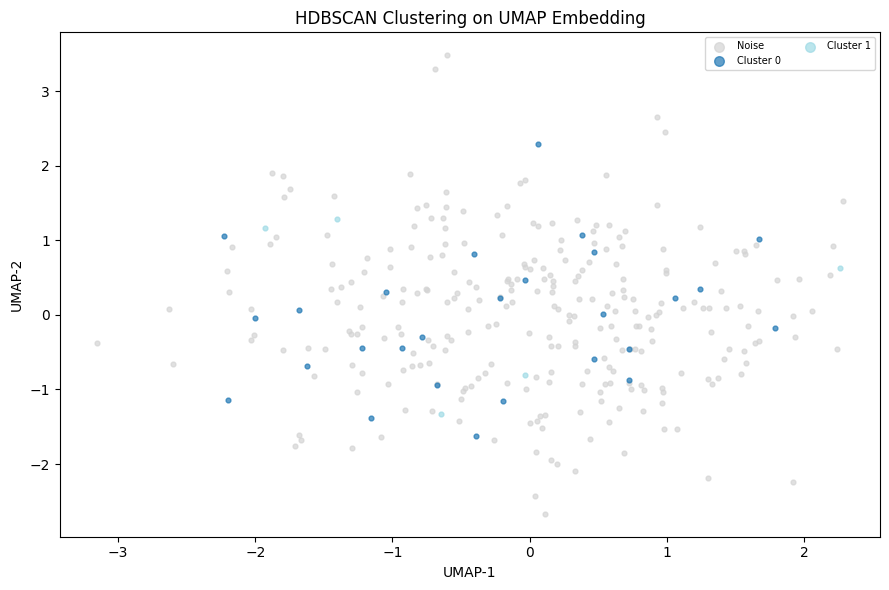

[13:47:19] DEPRECATION WARNING: please use MorganGenerator
[13:47:19] DEPRECATION WARNING: please use MorganGenerator
[13:47:19] DEPRECATION WARNING: please use MorganGenerator
[13:47:19] DEPRECATION WARNING: please use MorganGenerator
[13:47:19] DEPRECATION WARNING: please use MorganGenerator
[13:47:19] DEPRECATION WARNING: please use MorganGenerator
[13:47:19] DEPRECATION WARNING: please use MorganGenerator
[13:47:19] DEPRECATION WARNING: please use MorganGenerator
[13:47:19] DEPRECATION WARNING: please use MorganGenerator
[13:47:19] DEPRECATION WARNING: please use MorganGenerator
[13:47:19] DEPRECATION WARNING: please use MorganGenerator
[13:47:19] DEPRECATION WARNING: please use MorganGenerator
[13:47:19] DEPRECATION WARNING: please use MorganGenerator
[13:47:19] DEPRECATION WARNING: please use MorganGenerator
[13:47:19] DEPRECATION WARNING: please use MorganGenerator
[13:47:19] DEPRECATION WARNING: please use MorganGenerator
[13:47:19] DEPRECATION WARNING: please use MorganGenerat


Sphere exclusion: picked 100 diverse molecules from 2000 (radius=0.35)
SA score of diverse set: mean=2.81



Interactive plot saved → chemical_space_interactive.html
Open in browser for hover tooltips, zoom, and pan.


In [13]:
## 🥈 EXT-B | HDBSCAN Clustering + Sphere Exclusion + Plotly Interactive
# ─────────────────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import AllChem, DataStructs

# ── 1. HDBSCAN Clustering ─────────────────────────────────────────────────────
try:
    import hdbscan

    # Assumes fp_matrix (N × D) and umap_2d (N × 2) exist from earlier cells
    # Fall back to demo data if not available
    try:
        X_hdb = fp_matrix
        emb   = umap_2d
        names = df['name'].tolist() if 'name' in df.columns else [str(i) for i in range(len(X_hdb))]
    except NameError:
        print("fp_matrix / umap_2d not in scope — generating demo data")
        n = 300
        X_hdb = np.random.rand(n, 2048).astype(np.float32)
        # Simple 2D UMAP placeholder
        emb   = np.random.randn(n, 2)
        names = [f"mol_{i}" for i in range(n)]

    clusterer = hdbscan.HDBSCAN(min_cluster_size=5, min_samples=3,
                                  metric='euclidean', cluster_selection_method='eom')
    hdb_labels = clusterer.fit_predict(X_hdb)
    n_clusters = len(set(hdb_labels)) - (1 if -1 in hdb_labels else 0)
    n_noise    = (hdb_labels == -1).sum()
    print(f"HDBSCAN → {n_clusters} clusters | {n_noise} noise points "
          f"({n_noise/len(hdb_labels):.1%})")

    # Visualise on UMAP embedding
    palette = plt.cm.tab20(np.linspace(0, 1, max(n_clusters, 1)))
    plt.figure(figsize=(9, 6))
    for cl in sorted(set(hdb_labels)):
        mask = hdb_labels == cl
        color = 'lightgray' if cl == -1 else palette[cl % len(palette)]
        label = 'Noise' if cl == -1 else f'Cluster {cl}'
        plt.scatter(emb[mask, 0], emb[mask, 1], c=[color], s=12, alpha=0.7, label=label)
    plt.title('HDBSCAN Clustering on UMAP Embedding')
    plt.xlabel('UMAP-1'); plt.ylabel('UMAP-2')
    if n_clusters <= 15:
        plt.legend(markerscale=2, fontsize=7, ncol=2)
    plt.tight_layout(); plt.show()

except ImportError:
    print("hdbscan not installed. Run:  pip install hdbscan")

# ── 2. Sphere Exclusion Diversity Picker ─────────────────────────────────────
def sphere_exclusion_picker(smiles_list, radius=0.4, n_picks=50):
    """
    Greedy sphere exclusion: pick molecules whose Tanimoto distance from all
    previously picked molecules exceeds `radius`.
    Returns indices of selected molecules.
    """
    fps = []
    valid_idx = []
    for i, smi in enumerate(smiles_list):
        mol = Chem.MolFromSmiles(str(smi))
        if mol is None: continue
        fps.append(AllChem.GetMorganFingerprintAsBitVect(mol, 2, nBits=2048))
        valid_idx.append(i)

    picked     = [0]
    picked_fps = [fps[0]]

    for i in range(1, len(fps)):
        sims = DataStructs.BulkTanimotoSimilarity(fps[i], picked_fps)
        if max(sims) < (1 - radius):
            picked.append(i)
            picked_fps.append(fps[i])
        if len(picked) >= n_picks:
            break

    return [valid_idx[p] for p in picked]

try:
    smiles_col = 'smiles' if 'smiles' in df_chembl.columns else df_chembl.columns[0]
    picked_idx = sphere_exclusion_picker(df_chembl[smiles_col].tolist(),
                                         radius=0.35, n_picks=100)
    df_diverse = df_chembl.iloc[picked_idx].reset_index(drop=True)
    print(f"\nSphere exclusion: picked {len(df_diverse)} diverse molecules "
          f"from {len(df_chembl)} (radius=0.35)")
    if 'SA_score' in df_diverse.columns:
        print(f"SA score of diverse set: mean={df_diverse['SA_score'].mean():.2f}")
except Exception as e:
    print(f"Sphere exclusion skipped: {e}")

# ── 3. Interactive Plotly Scatter (HTML export) ───────────────────────────────
try:
    import plotly.express as px

    plot_df = pd.DataFrame({
        'x':       emb[:, 0],
        'y':       emb[:, 1],
        'cluster': hdb_labels.astype(str),
        'name':    names,
    })
    if 'SA_score' in df_chembl.columns and len(df_chembl) == len(plot_df):
        plot_df['SA_score'] = df_chembl['SA_score'].values

    hover_cols = ['name', 'SA_score'] if 'SA_score' in plot_df.columns else ['name']
    fig = px.scatter(
        plot_df, x='x', y='y',
        color='cluster',
        hover_data=hover_cols,
        title='Interactive Chemical Space (HDBSCAN clusters)',
        width=900, height=600,
    )
    out_html = 'chemical_space_interactive.html'
    fig.write_html(out_html)
    fig.show()
    print(f"\nInteractive plot saved → {out_html}")
    print("Open in browser for hover tooltips, zoom, and pan.")
except ImportError:
    print("plotly not installed. Run:  pip install plotly")
except Exception as e:
    print(f"Plotly plot skipped: {e}")


NetworkX 3.6.1
Building similarity graph on 300 molecules ...
Graph: 300 nodes, 2262 edges (Tanimoto ≥ 0.4)
Density: 0.0504

Top-10 highest-degree (most connected) molecules:
   1. node=174  degree_centrality=0.1237  SMILES=Cc1ccc(Sc2cncc3sc(C(N)=O)cc23)cc1...
   2. node=186  degree_centrality=0.1237  SMILES=Cc1cc(C)cc(Sc2cncc3sc(C(N)=O)cc23)c1...
   3. node=187  degree_centrality=0.1237  SMILES=Cc1ccc(Sc2cncc3sc(C(N)=O)cc23)cc1C...
   4. node=188  degree_centrality=0.1237  SMILES=Cc1cccc(Sc2cncc3sc(C(N)=O)cc23)c1...
   5. node=196  degree_centrality=0.1237  SMILES=Cc1ccc(Sc2cncc3sc(C(=O)NN)cc23)cc1...
   6. node=198  degree_centrality=0.1237  SMILES=Cc1ccc(Sc2cncc3sc(C(=O)O)cc23)cc1...
   7. node=199  degree_centrality=0.1237  SMILES=CC(=O)c1cc2c(Sc3ccc(C)cc3)cncc2s1...
   8. node=201  degree_centrality=0.1237  SMILES=Cc1ccc(Sc2cncc3sc(C(=O)N=C(N)N)cc23)cc1...
   9. node=206  degree_centrality=0.1237  SMILES=COc1ccc(Sc2cncc3sc(C(N)=O)cc23)cc1...
  10. node=207  degree_centrality=0.123

[13:47:24] DEPRECATION WARNING: please use MorganGenerator
[13:47:24] DEPRECATION WARNING: please use MorganGenerator
[13:47:24] DEPRECATION WARNING: please use MorganGenerator
[13:47:24] DEPRECATION WARNING: please use MorganGenerator
[13:47:24] DEPRECATION WARNING: please use MorganGenerator
[13:47:24] DEPRECATION WARNING: please use MorganGenerator
[13:47:24] DEPRECATION WARNING: please use MorganGenerator
[13:47:24] DEPRECATION WARNING: please use MorganGenerator
[13:47:24] DEPRECATION WARNING: please use MorganGenerator
[13:47:24] DEPRECATION WARNING: please use MorganGenerator
[13:47:24] DEPRECATION WARNING: please use MorganGenerator
[13:47:24] DEPRECATION WARNING: please use MorganGenerator
[13:47:24] DEPRECATION WARNING: please use MorganGenerator
[13:47:24] DEPRECATION WARNING: please use MorganGenerator
[13:47:24] DEPRECATION WARNING: please use MorganGenerator
[13:47:24] DEPRECATION WARNING: please use MorganGenerator
[13:47:24] DEPRECATION WARNING: please use MorganGenerat

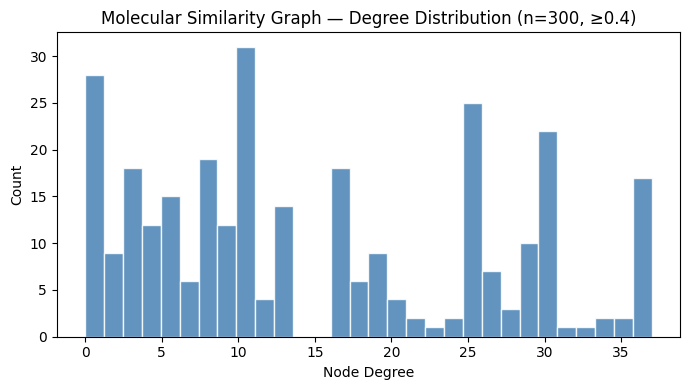


Most common Murcko scaffolds among top-50 connected molecules:
  Count= 1  Scaffold: Cc1ccc(Sc2cncc3sc(C(N)=O)cc23)cc1
  Count= 1  Scaffold: Cc1cc(C)cc(Sc2cncc3sc(C(N)=O)cc23)c1
  Count= 1  Scaffold: Cc1ccc(Sc2cncc3sc(C(N)=O)cc23)cc1C
  Count= 1  Scaffold: Cc1cccc(Sc2cncc3sc(C(N)=O)cc23)c1
  Count= 1  Scaffold: Cc1ccc(Sc2cncc3sc(C(=O)NN)cc23)cc1

(Graph visualization skipped for n=300 > 100 nodes — reduce dataset or increase threshold)


In [14]:
## 🥉 EXT-C | Molecular Similarity Graph (NetworkX) + Scaffold Centrality
# ─────────────────────────────────────────────────────────────────────────────
# Nodes = molecules; Edges = Tanimoto similarity > threshold
# Identifies most "connected" (chemically diverse) scaffolds
# ─────────────────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from rdkit import Chem
from rdkit.Chem import AllChem, DataStructs
from rdkit.Chem.Scaffolds import MurckoScaffold

NETWORKX_AVAILABLE = False
try:
    import networkx as nx
    NETWORKX_AVAILABLE = True
    print(f"NetworkX {nx.__version__}")
except ImportError:
    print("networkx not installed. Run:  pip install networkx")

if NETWORKX_AVAILABLE:
    # ── 1. Select subset for graph (cap at 300 nodes for performance) ─────────
    smiles_col = 'smiles' if 'smiles' in df_chembl.columns else df_chembl.columns[0]
    try:
        mol_df = df_chembl[[smiles_col]].copy().dropna().head(300).reset_index(drop=True)
    except NameError:
        # Fallback: use df from earlier cells
        try:
            mol_df = df[[smiles_col]].copy().dropna().head(300).reset_index(drop=True)
        except Exception:
            print("No molecule DataFrame in scope — aborting")
            mol_df = pd.DataFrame()

    if len(mol_df) == 0:
        raise RuntimeError("No molecule data available")

    # ── 2. Compute Morgan fingerprints ────────────────────────────────────────
    fps, valid_idx = [], []
    for i, smi in enumerate(mol_df[smiles_col]):
        mol = Chem.MolFromSmiles(str(smi))
        if mol:
            fps.append(AllChem.GetMorganFingerprintAsBitVect(mol, 2, nBits=1024))
            valid_idx.append(i)
    mol_df = mol_df.iloc[valid_idx].reset_index(drop=True)
    n      = len(fps)
    print(f"Building similarity graph on {n} molecules ...")

    # ── 3. Build NetworkX graph (Tanimoto threshold = 0.4) ────────────────────
    SIM_THRESHOLD = 0.4
    G = nx.Graph()
    G.add_nodes_from(range(n))
    edge_count = 0
    for i in range(n):
        sims = DataStructs.BulkTanimotoSimilarity(fps[i], fps[i+1:])
        for j_offset, sim in enumerate(sims):
            if sim >= SIM_THRESHOLD:
                G.add_edge(i, i + 1 + j_offset, weight=float(sim))
                edge_count += 1

    print(f"Graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges "
          f"(Tanimoto ≥ {SIM_THRESHOLD})")
    density = nx.density(G)
    print(f"Density: {density:.4f}")

    # ── 4. Degree Centrality ──────────────────────────────────────────────────
    deg_centrality = nx.degree_centrality(G)
    top_nodes      = sorted(deg_centrality, key=deg_centrality.get, reverse=True)[:10]
    print("\nTop-10 highest-degree (most connected) molecules:")
    for rank, node in enumerate(top_nodes, 1):
        smi = mol_df[smiles_col].iloc[node]
        print(f"  {rank:2d}. node={node:3d}  degree_centrality={deg_centrality[node]:.4f}  "
              f"SMILES={smi[:40]}...")

    # ── 5. Degree Distribution ────────────────────────────────────────────────
    degrees = [d for _, d in G.degree()]
    plt.figure(figsize=(7, 4))
    plt.hist(degrees, bins=30, color='steelblue', edgecolor='white', alpha=0.85)
    plt.xlabel('Node Degree'); plt.ylabel('Count')
    plt.title(f'Molecular Similarity Graph — Degree Distribution (n={n}, ≥{SIM_THRESHOLD})')
    plt.tight_layout(); plt.show()

    # ── 6. Most Connected Scaffold ────────────────────────────────────────────
    def get_murcko_scaffold(smi):
        mol = Chem.MolFromSmiles(str(smi))
        if mol is None: return 'INVALID'
        try:
            core = MurckoScaffold.MurckoDecompose(mol)
            return Chem.MolToSmiles(core)
        except Exception:
            return smi

    # Get scaffolds for top-50 most connected nodes
    top50_nodes     = sorted(deg_centrality, key=deg_centrality.get, reverse=True)[:50]
    top50_smiles    = mol_df[smiles_col].iloc[top50_nodes].tolist()
    top50_scaffolds = [get_murcko_scaffold(s) for s in top50_smiles]
    scaffold_counts = Counter(top50_scaffolds)
    most_common_sc  = scaffold_counts.most_common(5)

    print("\nMost common Murcko scaffolds among top-50 connected molecules:")
    for scaffold, count in most_common_sc:
        print(f"  Count={count:2d}  Scaffold: {scaffold[:60]}")

    # ── 7. Graph Visualization (small subset) ─────────────────────────────────
    if n <= 100:
        plt.figure(figsize=(10, 8))
        pos      = nx.spring_layout(G, seed=42, k=0.5)
        node_col = [deg_centrality[v] for v in G.nodes()]
        edges    = G.edges(data=True)
        weights  = [d['weight'] * 2 for _, _, d in edges]
        nx.draw_networkx_nodes(G, pos, node_color=node_col,
                               cmap='coolwarm', node_size=60, alpha=0.85)
        nx.draw_networkx_edges(G, pos, width=weights, alpha=0.25, edge_color='gray')
        sm = plt.cm.ScalarMappable(cmap='coolwarm',
             norm=plt.Normalize(min(node_col), max(node_col)))
        sm.set_array([])
        plt.colorbar(sm, label='Degree Centrality')
        plt.title(f'Molecular Similarity Network (Tanimoto ≥ {SIM_THRESHOLD})')
        plt.axis('off'); plt.tight_layout(); plt.show()
    else:
        print(f"\n(Graph visualization skipped for n={n} > 100 nodes — "
              "reduce dataset or increase threshold)")
